In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
# importing the data
titanic_test=pd.read_csv('/content/Titanic_test.csv')
titanic_train=pd.read_csv('/content/Titanic_train.csv')
titanic_test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [3]:
titanic_train

In [5]:
titanic_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
titanic_train.info()# information about the train dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
titanic_train.describe()# describing the train data details

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


* The minimum age of a passenger is 0.42 means a newly born baby
* The maximum age of a passenger is 80 and median of age is 28 and mean is 29.699. That means the max no of passengers belongs to 28 to 30.
* The minimum fare of a ticket is 0 and max is 512.

In [30]:
df = titanic_train.copy()
df['Age'].fillna(df['Age'].mean(),inplace=True) # Added imputation here
df['Embarked'].fillna('s', inplace=True) # Added Embarked imputation here as well

In [33]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,2


In [34]:
df.drop(['PassengerId','Ticket','Cabin'], axis = 1 ,inplace = True) # droping the data its not requred   for model
df.head(5)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,7.2500,2
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,71.2833,0
2,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,7.9250,2
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,53.1000,2
4,0,3,"Allen, Mr. William Henry",1,35.0,0,0,8.0500,2


In [35]:
df.isnull().sum()# checking the null values

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [36]:
df['Age'].fillna(df['Age'].mean(),inplace=True)
df.isnull().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [37]:
df['Embarked'].value_counts()# in this having string so we have to find value count of particular strings

,count
Embarked,
2,644
0,168
1,77
3,2


In [38]:
df['Embarked'].fillna('s',inplace=True)#here applying mode to fill the nullvalues

In [39]:
df.isnull().sum()#after filling the null values

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


# Visualization

(array([549.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
        342.]),
 array([0.        , 0.08333333, 0.16666667, 0.25      , 0.33333333,
        0.41666667, 0.5       , 0.58333333, 0.66666667, 0.75      ,
        0.83333333, 0.91666667, 1.        ]),
 <BarContainer object of 12 artists>)

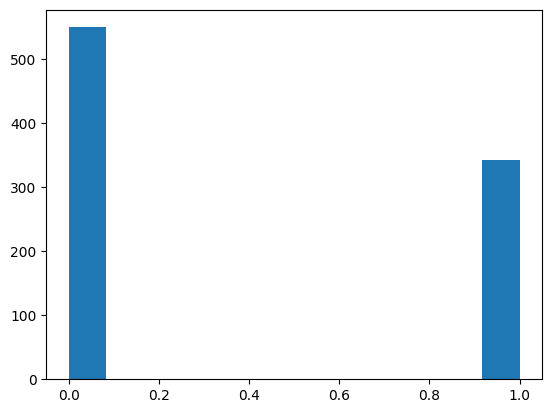

In [40]:
plt.hist(x ='Survived' , bins = 12,data =df)

<Axes: >

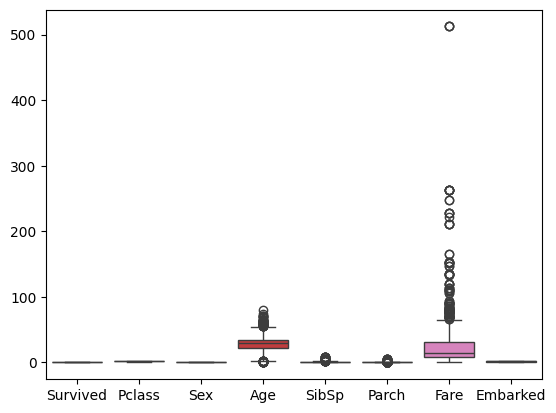

In [41]:
sns.boxplot(data = df)

In [42]:
df.head(3)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,7.2500,2
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,71.2833,0
2,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,7.9250,2


In [43]:
df['Sex'].value_counts().reset_index()

,Sex,count
0,1,577
1,0,314


<Axes: xlabel='Survived', ylabel='count'>

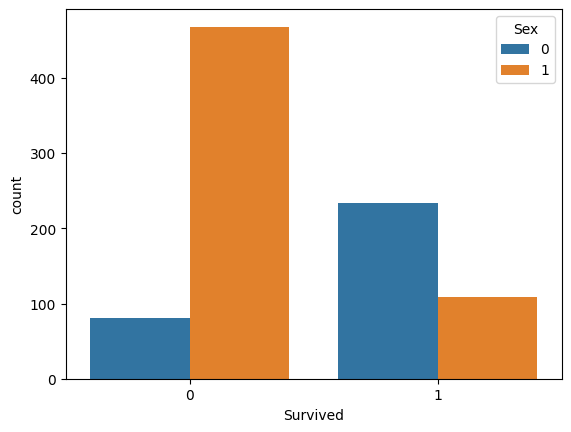

In [44]:
sns.countplot(x='Survived',hue='Sex',data = df)

<Axes: xlabel='Survived', ylabel='count'>

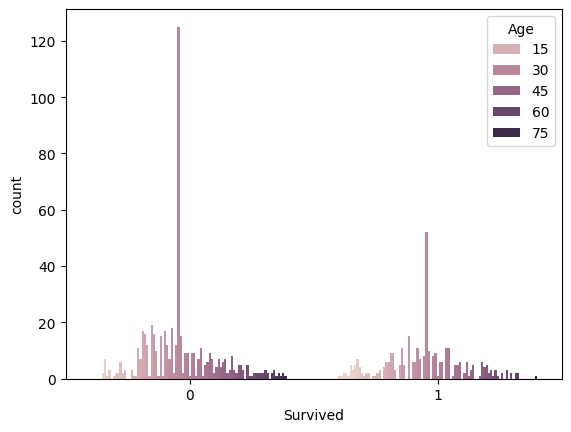

In [45]:
sns.countplot(x='Survived',hue="Age",data=df)

<Axes: xlabel='Survived', ylabel='count'>

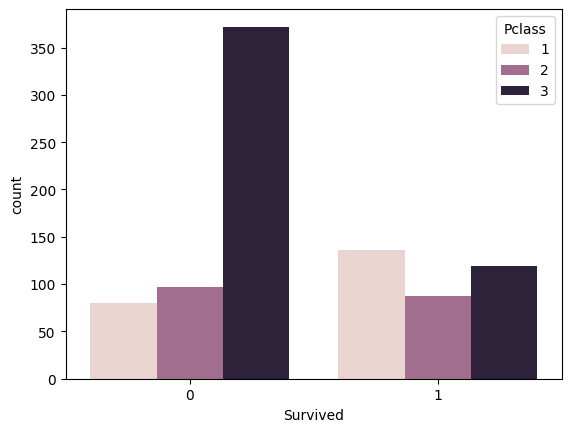

In [46]:
sns.countplot(x='Survived',hue='Pclass',data=df)

In [47]:
df['Age'].value_counts().reset_index()

,Age,count
0,29.699118,177
1,24.000000,30
2,22.000000,27
3,18.000000,26
4,28.000000,25
...,...,...
84,24.500000,1
85,0.670000,1
86,0.420000,1
87,34.500000,1


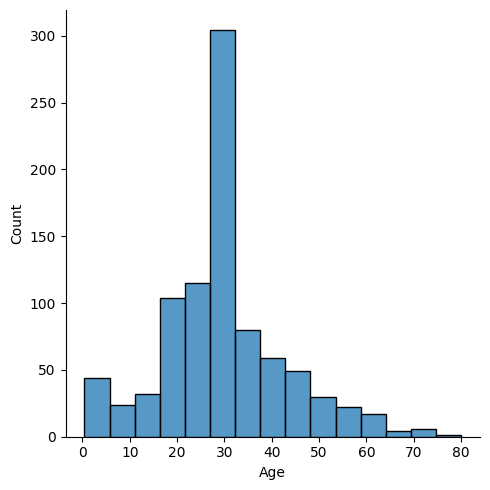

In [48]:
sns.displot(x = 'Age',bins = 15,data = df)

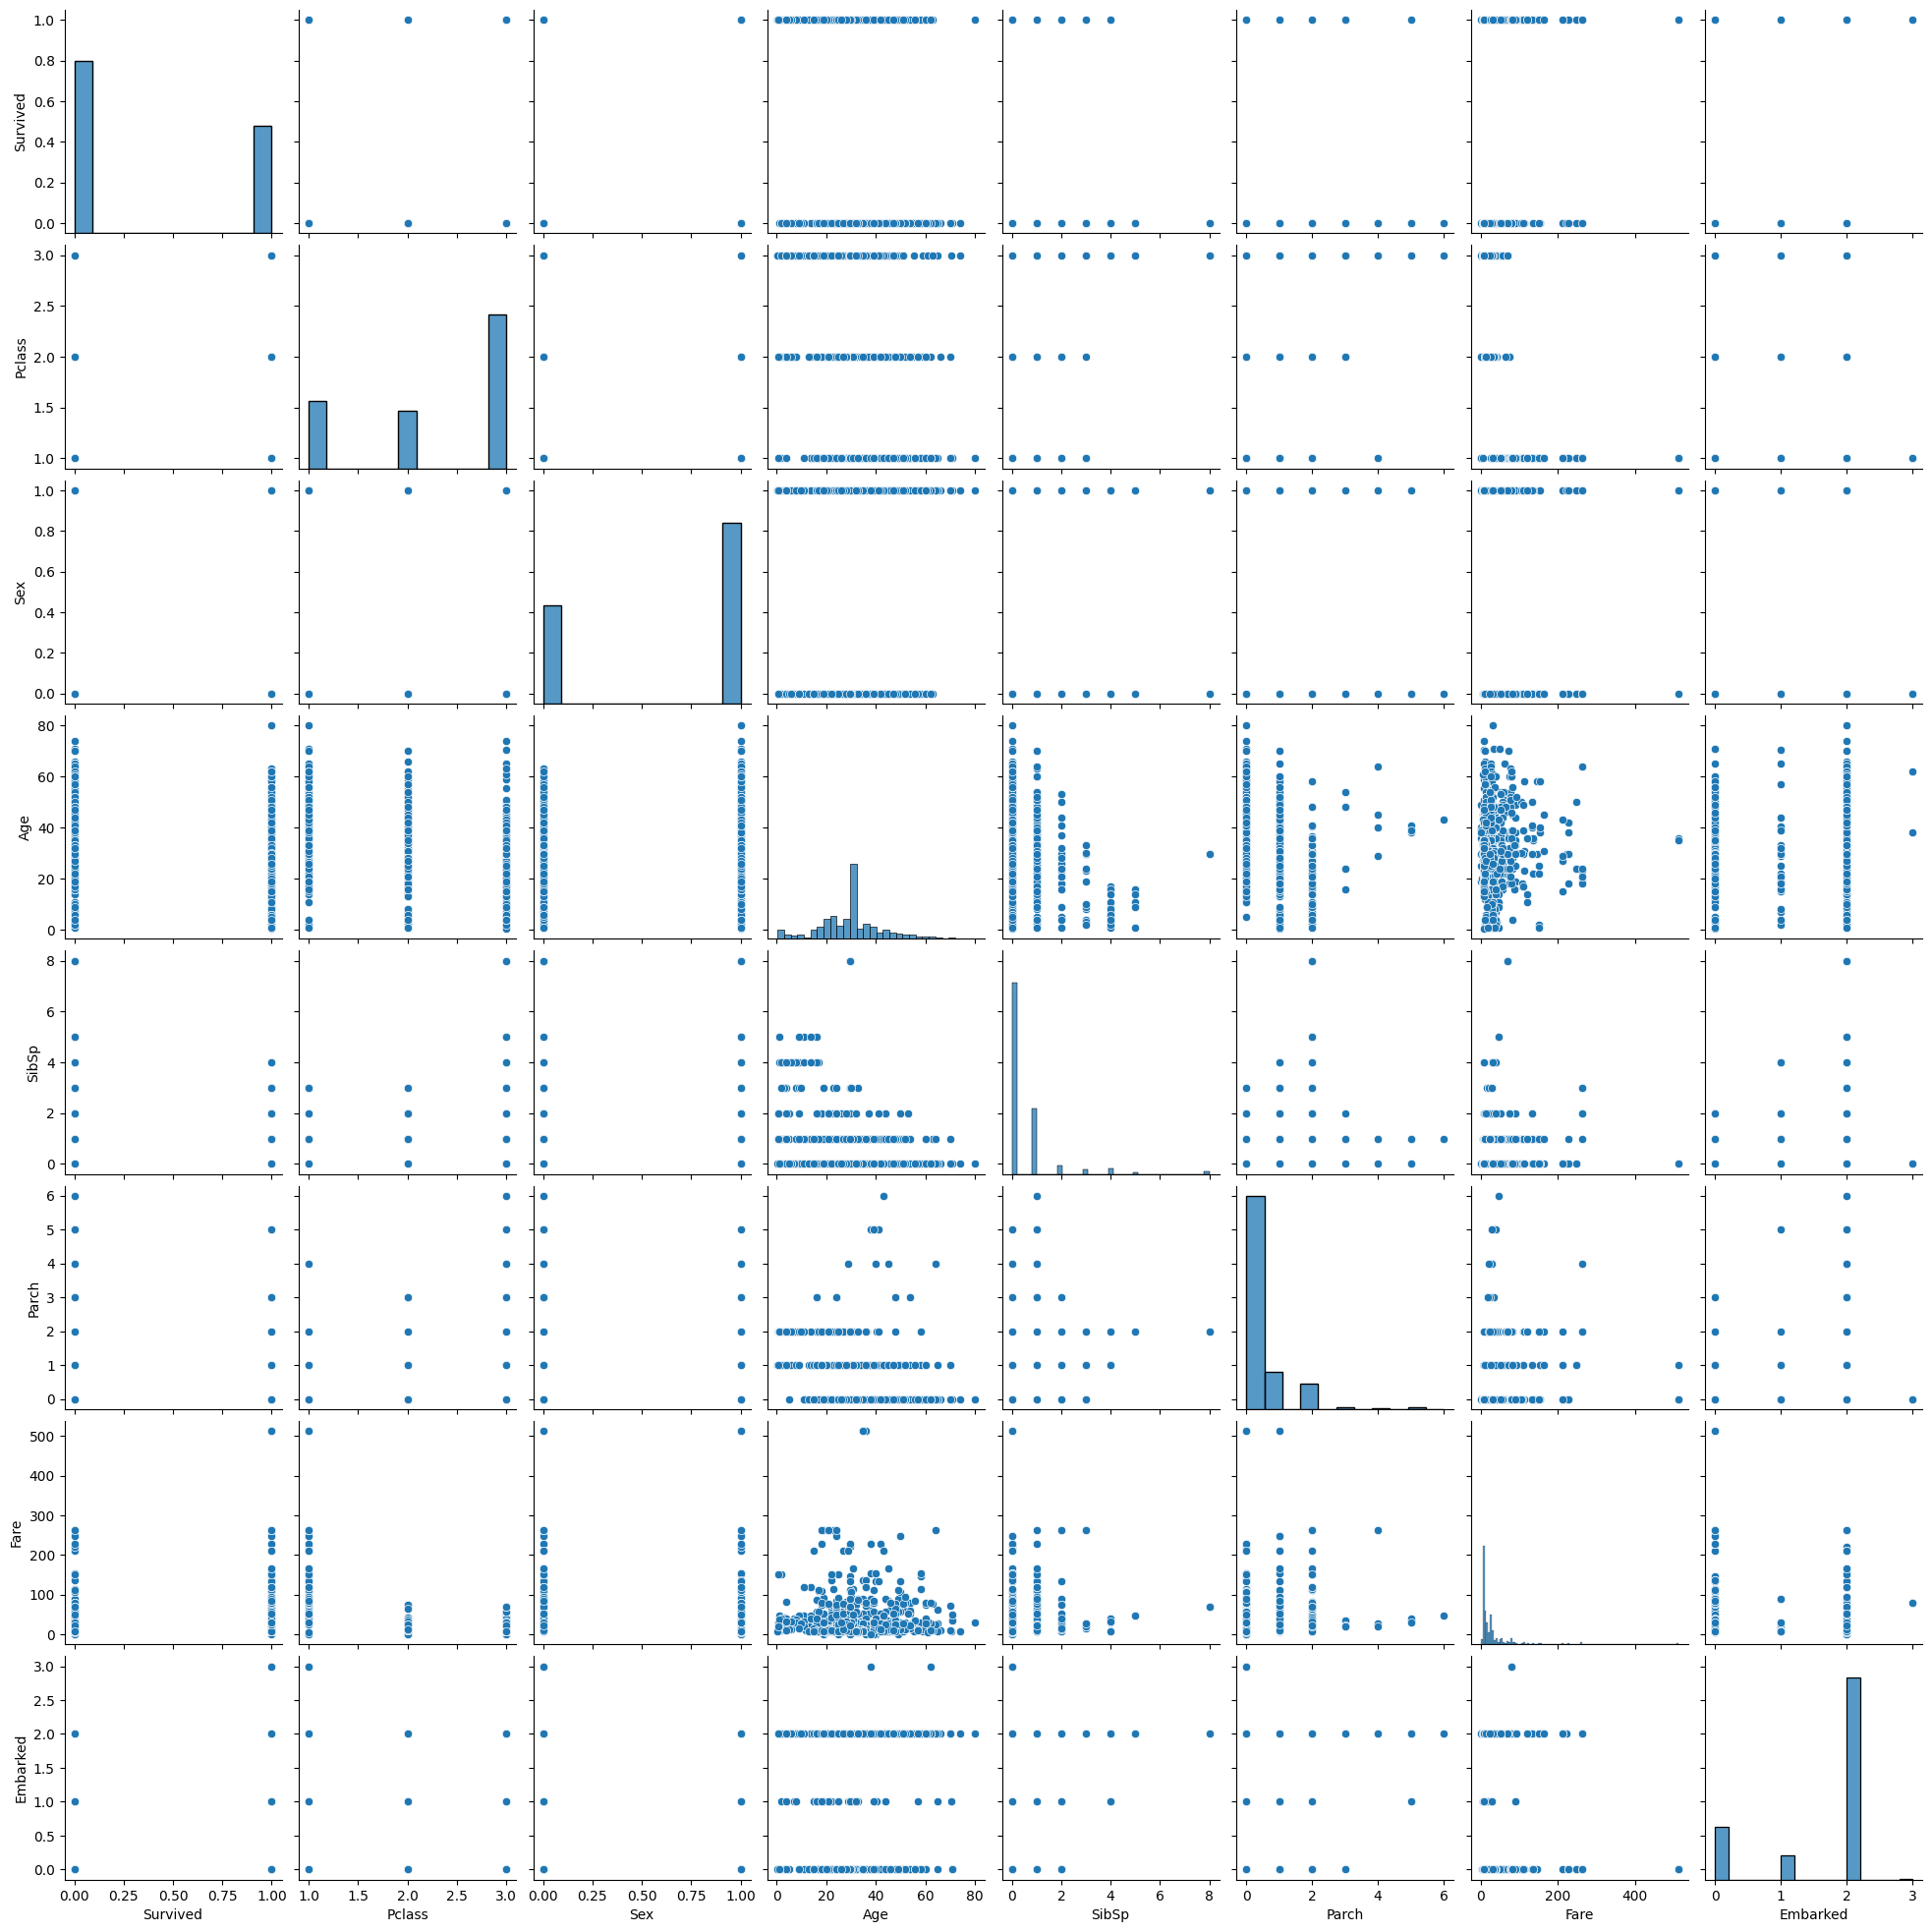

In [49]:
sns.pairplot(df)

# Model Building

In [50]:
df.head(6)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",1,22.000000,1,0,7.2500,2
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.000000,1,0,71.2833,0
2,1,3,"Heikkinen, Miss. Laina",0,26.000000,0,0,7.9250,2
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.000000,1,0,53.1000,2
4,0,3,"Allen, Mr. William Henry",1,35.000000,0,0,8.0500,2
5,0,3,"Moran, Mr. James",1,29.699118,0,0,8.4583,1


In [51]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
lable_er = LabelEncoder()

In [52]:
df['Sex'] = lable_er.fit_transform(df['Sex'])
df['Embarked'] = lable_er.fit_transform(df['Embarked'])

In [53]:
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",1,22.000000,1,0,7.2500,2
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.000000,1,0,71.2833,0
2,1,3,"Heikkinen, Miss. Laina",0,26.000000,0,0,7.9250,2
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.000000,1,0,53.1000,2
4,0,3,"Allen, Mr. William Henry",1,35.000000,0,0,8.0500,2
...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",1,27.000000,0,0,13.0000,2
887,1,1,"Graham, Miss. Margaret Edith",0,19.000000,0,0,30.0000,2
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,29.699118,1,2,23.4500,2
889,1,1,"Behr, Mr. Karl Howell",1,26.000000,0,0,30.0000,0


In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,roc_curve, confusion_matrix
from sklearn.model_selection import train_test_split

In [55]:
!pip install klib

In [56]:
import klib # correlation matrix using klib
klib.corr_mat(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
Survived,1.00,-0.34,-0.54,-0.07,-0.04,0.08,0.26,-0.16
Pclass,-0.34,1.00,0.13,-0.33,0.08,0.02,-0.55,0.16
Sex,-0.54,0.13,1.00,0.08,-0.11,-0.25,-0.18,0.10
Age,-0.07,-0.33,0.08,1.00,-0.23,-0.18,0.09,-0.02
SibSp,-0.04,0.08,-0.11,-0.23,1.00,0.41,0.16,0.07
Parch,0.08,0.02,-0.25,-0.18,0.41,1.00,0.22,0.04
Fare,0.26,-0.55,-0.18,0.09,0.16,0.22,1.00,-0.22
Embarked,-0.16,0.16,0.10,-0.02,0.07,0.04,-0.22,1.00


In [57]:
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
y = df['Survived']

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [60]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')
print(f'ROC AUC Score: {roc_auc:.2f}')


Accuracy: 0.81
Precision: 0.79
Recall: 0.74
F1 Score: 0.76
ROC AUC Score: 0.88


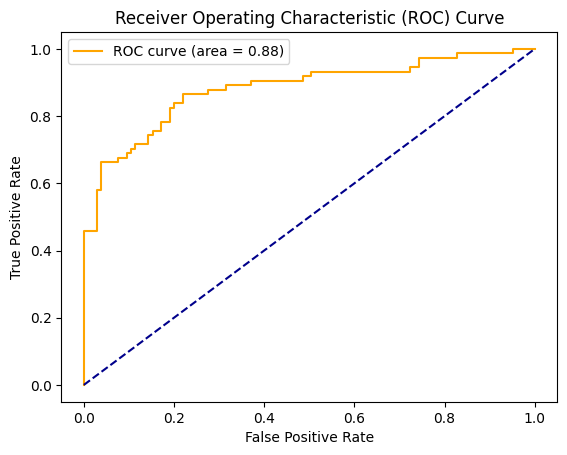

In [62]:
fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
plt.plot(fpr, tpr, color='orange', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

In [63]:
# 8. Feature Importance (Coefficients)
# ==========================
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)
print(coefficients)

    Feature  Coefficient
5      Fare     0.126167
4     Parch    -0.102034
6  Embarked    -0.170740
3     SibSp    -0.351979
2       Age    -0.403486
0    Pclass    -0.782802
1       Sex    -1.279726


In [64]:
import joblib

# Save the trained model to a file
joblib.dump(model, "titanic_logistic_model.pkl")

print("Model saved as titanic_logistic_model.pkl")

Model saved as titanic_logistic_model.pkl


In [65]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 116.4 MB/s eta 0:00:00


In [66]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib

In [67]:
# Load model
model = joblib.load("titanic_logistic_model.pkl")

st.title(" Titanic Survival Prediction (Logistic Regression)")

st.sidebar.header("Passenger Information")
pclass = st.sidebar.selectbox("Passenger Class", [1, 2, 3])
sex = st.sidebar.selectbox("Sex", ["male", "female"])
age = st.sidebar.slider("Age", 1, 80, 25)
sibsp = st.sidebar.number_input("Number of Siblings/Spouses Aboard", 0, 8, 0)
parch = st.sidebar.number_input("Number of Parents/Children Aboard", 0, 6, 0)
fare = st.sidebar.slider("Fare", 0.0, 500.0, 50.0)
embarked = st.sidebar.selectbox("Port of Embarkation", ["C", "Q", "S"])

# Encode categorical
sex = 1 if sex == "male" else 0
embarked_dict = {"C": 0, "Q": 1, "S": 2}
embarked = embarked_dict[embarked]

# Create input array
input_data = np.array([[pclass, sex, age, sibsp, parch, fare, embarked]])
prediction = model.predict(input_data)[0]
prob = model.predict_proba(input_data)[0][1]

st.subheader("Prediction Result")
if prediction == 1:
    st.success(f" Passenger is likely to **Survive** (Probability: {prob:.2f})")
else:
    st.error(f" Passenger is likely **Not to Survive** (Probability: {prob:.2f})")

2025-10-15 16:35:26.052 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-15 16:35:26.216 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-10-15 16:35:26.216 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-15 16:35:26.217 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-15 16:35:26.222 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-15 16:35:26.224 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-15 16:35:26.225 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-15 16:35:26.226 Thread 'MainThread': mi

# Interview Questions:

1.What is the difference between precision and recall?        
Precision measures how many of the predicted positive cases are actually positive.
It answers: “When the model predicts positive, how often is it correct?”
Formula: Precision = TP / (TP + FP)       

 Recall (also called Sensitivity or True Positive Rate) measures how many of the actual positive cases were correctly identified.
It answers: “How many of the real positives did the model detect?”
Formula: Recall = TP / (TP + FN)
High recall means fewer false negatives

2.What is Cross-Validation, and why is it important in Binary Classification?         
Cross-validation is a model evaluation technique used to assess how well a machine learning model generalizes to unseen data.       

The most common form is k-fold cross-validation, where the dataset is divided into k subsets (folds). The model trains on k-1 folds and tests on the remaining one, repeating this process k times.              

The average performance across all folds gives a more reliable estimate of model accuracy.           

In binary classification, cross-validation is important because it ensures that both classes (positive and negative) are fairly represented in training and testing, preventing biased performance estimates.       

It helps reduce overfitting, ensures stability of results, and provides a more accurate evaluation than a single train-test split.